# Project Notebook v2 — Part 2: Visualizations

Exploratory plots split out of `project_notebook_v2.ipynb`. Requires the artifacts written by **Part 1 (data prep)** — run that notebook first.

In [1]:
# --- Load prepared data (run project_notebook_v2_data_prep.ipynb first) ---
import json

import numpy as np
import pandas as pd

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

df = pd.read_pickle('artifacts/df_clean.pkl')       # cleaned full dataset
cohort = pd.read_pickle('artifacts/cohort.pkl')     # modelling cohort (with target)
data = pd.read_pickle('artifacts/data.pkl')         # modelling frame (features + target + died)
with open('artifacts/feature_lists.json') as f:
    _fl = json.load(f)
numeric_features = _fl['numeric_features']
binary_features = _fl['binary_features']
categorical_features = _fl['categorical_features']
comorbidity_cols = _fl['comorbidity_cols']
feature_cols = _fl['feature_cols']

X = data[feature_cols]
y = data['target']
print(f"Loaded: df {df.shape} | cohort {cohort.shape} | data {data.shape} | X {X.shape}")

Loaded: df (263007, 42) | cohort (263007, 43) | data (260933, 23) | X (260933, 21)


### Exploratory analysis (full cohort)

These plots are **descriptive** and use the full cleaned cohort to characterise the data. They inform understanding only — all model fitting, selection, and metrics still respect the train/test split defined above, so no test information leaks into modelling decisions. The plots target: (1) the dominant predictor, age; (2) comorbidity burden and sex; (3) class balance; (4) a dataset-level time series of daily positive cases vs. hospital admissions; and (5) a KMeans clustering of patients on age, sex, and comorbidity count (the outcome is **not** a clustering input), shown as two side-by-side interactive 3D scatters (opened in the browser) — the left coloured by cluster, the right coloured by hospitalization outcome — plus per-cluster profiles.

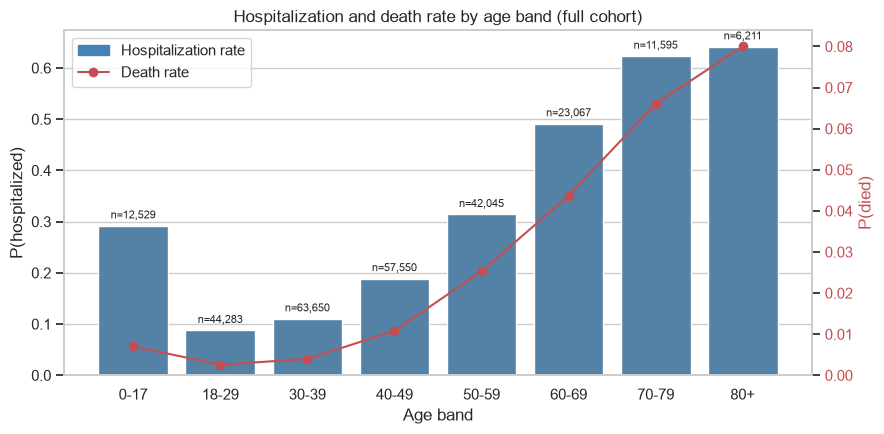

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

sns.set_theme(style='whitegrid')

# EDA plot 1: hospitalization AND death rate by age band (full cohort)
age_bins = [0, 18, 30, 40, 50, 60, 70, 80, 120]
age_labels = ['0-17', '18-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80+']
tmp = data.assign(age_band=pd.cut(data['age'], bins=age_bins,
                                  labels=age_labels, right=False))
by_age = tmp.groupby('age_band', observed=True).agg(
    hosp=('target', 'mean'), death=('died', 'mean'), size=('target', 'size'))

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(x=by_age.index, y=by_age['hosp'], color='steelblue', ax=ax)
ax.set_title('Hospitalization and death rate by age band (full cohort)')
ax.set_xlabel('Age band'); ax.set_ylabel('P(hospitalized)')
for i, (m, n) in enumerate(zip(by_age['hosp'], by_age['size'])):
    ax.text(i, m + 0.01, f'n={n:,}', ha='center', va='bottom', fontsize=8)

# Death rate overlaid on a secondary axis (much smaller scale than hospitalization).
ax2 = ax.twinx()
ax2.plot(range(len(by_age)), by_age['death'], 'o-', color='#C44E52')
ax2.set_ylabel('P(died)', color='#C44E52')
ax2.tick_params(axis='y', labelcolor='#C44E52')
ax2.set_ylim(bottom=0); ax2.grid(False)

ax.legend(handles=[Patch(color='steelblue', label='Hospitalization rate'),
                   Line2D([0], [0], color='#C44E52', marker='o', label='Death rate')],
          loc='upper left')
plt.tight_layout(); plt.show()

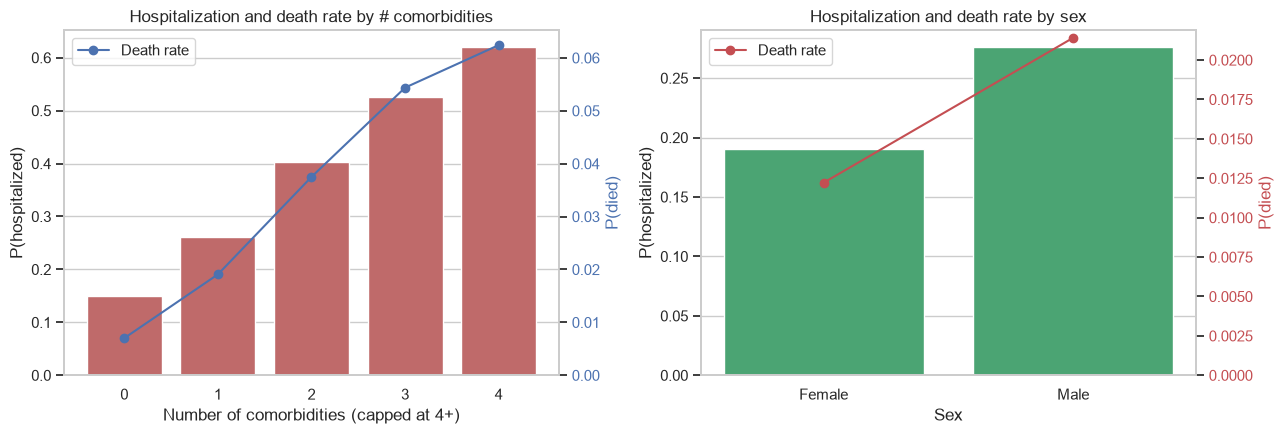

In [3]:
# EDA plot 2: hospitalization AND death rate by comorbidity burden and by sex (full cohort)
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# --- Left: by number of comorbidities ---
n_comorb = data[comorbidity_cols].fillna(0).sum(axis=1).clip(upper=4)
comorb_df = pd.DataFrame({'n_comorb': n_comorb.astype(int),
                          'target': data['target'], 'died': data['died']})
by_comorb = comorb_df.groupby('n_comorb').agg(hosp=('target', 'mean'), death=('died', 'mean'))
sns.barplot(x=by_comorb.index, y=by_comorb['hosp'], color='indianred', ax=axes[0])
axes[0].set_title('Hospitalization and death rate by # comorbidities')
axes[0].set_xlabel('Number of comorbidities (capped at 4+)')
axes[0].set_ylabel('P(hospitalized)')
ax0b = axes[0].twinx()
ax0b.plot(range(len(by_comorb)), by_comorb['death'], 'o-', color='#4C72B0')
ax0b.set_ylabel('P(died)', color='#4C72B0')
ax0b.tick_params(axis='y', labelcolor='#4C72B0')
ax0b.set_ylim(bottom=0); ax0b.grid(False)
axes[0].legend(handles=[Line2D([0], [0], color='#4C72B0', marker='o', label='Death rate')],
               loc='upper left')

# --- Right: by sex ---
by_sex = data.groupby('sex').agg(hosp=('target', 'mean'),
                                 death=('died', 'mean')).sort_values('hosp')
sns.barplot(x=by_sex.index, y=by_sex['hosp'], color='mediumseagreen', ax=axes[1])
axes[1].set_title('Hospitalization and death rate by sex')
axes[1].set_xlabel('Sex'); axes[1].set_ylabel('P(hospitalized)')
ax1b = axes[1].twinx()
ax1b.plot(range(len(by_sex)), by_sex['death'], 'o-', color='#C44E52')
ax1b.set_ylabel('P(died)', color='#C44E52')
ax1b.tick_params(axis='y', labelcolor='#C44E52')
ax1b.set_ylim(bottom=0); ax1b.grid(False)
axes[1].legend(handles=[Line2D([0], [0], color='#C44E52', marker='o', label='Death rate')],
               loc='upper left')

plt.tight_layout(); plt.show()

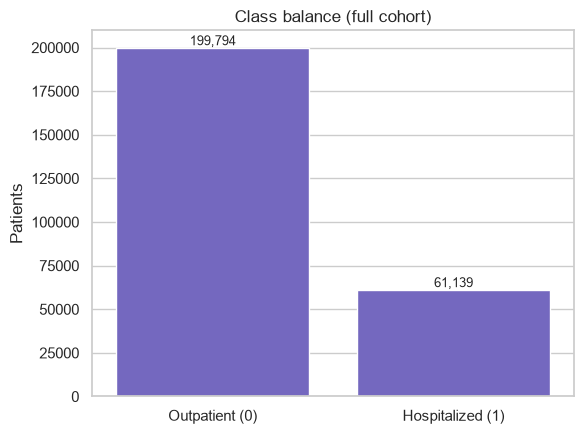

In [4]:
# EDA plot 3: class balance (full cohort)
fig, ax = plt.subplots(figsize=(6, 4.5))
cb = y.value_counts().sort_index()
sns.barplot(x=['Outpatient (0)', 'Hospitalized (1)'], y=cb.values, color='slateblue', ax=ax)
ax.set_title('Class balance (full cohort)')
ax.set_ylabel('Patients')
for i, v in enumerate(cb.values):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()

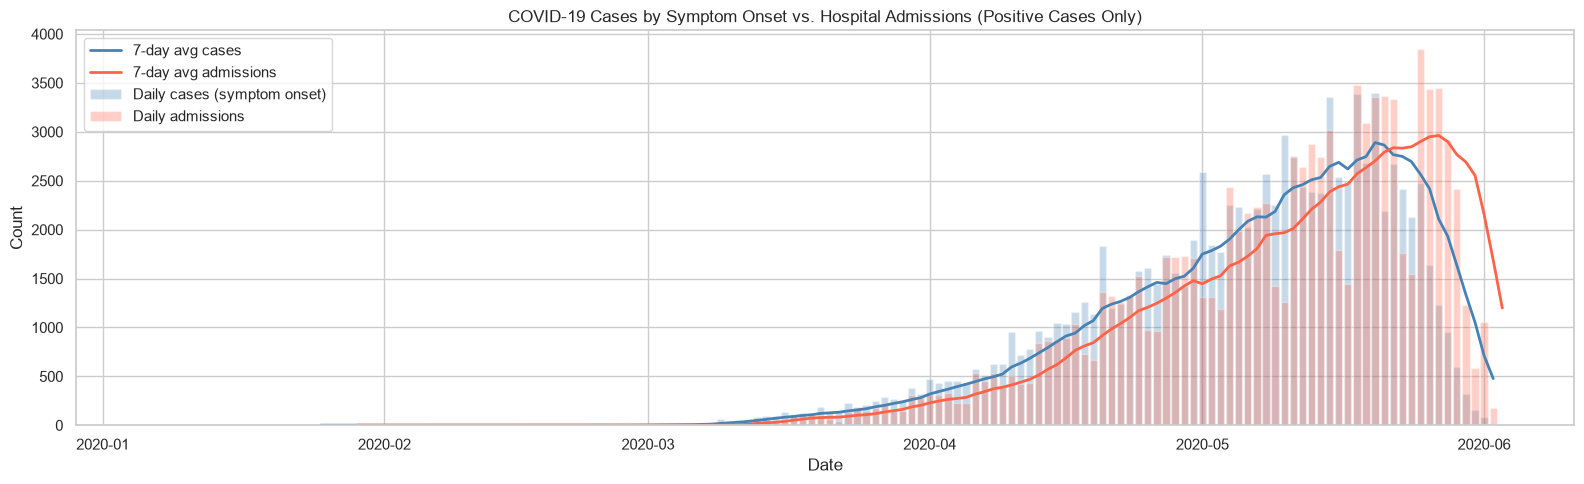

In [5]:
# EDA plot 4: dataset-level time series — daily positive cases vs. hospital admissions
positives = df[df['result'] == 'Positive']

daily_cases = (
    positives
    .groupby('symptoms_onset_date')
    .size()
    .rename('new_cases')
    .sort_index()
)
rolling_avg = daily_cases.rolling(window=7).mean()

daily_admissions = (
    positives
    .groupby('admission_date')
    .size()
    .rename('admissions')
    .sort_index()
)
rolling_avg_adm = daily_admissions.rolling(window=7).mean()

fig, ax = plt.subplots(figsize=(16, 5))

ax.bar(daily_cases.index, daily_cases, color='steelblue', alpha=0.3, label='Daily cases (symptom onset)')
ax.plot(rolling_avg.index, rolling_avg, color='steelblue', linewidth=2, label='7-day avg cases')

ax.bar(daily_admissions.index, daily_admissions, color='tomato', alpha=0.3, label='Daily admissions')
ax.plot(rolling_avg_adm.index, rolling_avg_adm, color='tomato', linewidth=2, label='7-day avg admissions')

ax.set_title('COVID-19 Cases by Symptom Onset vs. Hospital Admissions (Positive Cases Only)')
ax.set_xlabel('Date')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
# EDA plot 5: KMeans clustering on [age, sex, #comorbidities] (target is NOT an input).
# Two interactive 3D scatters side by side, opened in the browser:
# left coloured by KMeans cluster, right coloured by hospitalization outcome.
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

pio.renderers.default = 'browser'

clust = pd.DataFrame({
    'age': data['age'],
    'sex': data['sex'].map({'Female': 0, 'Male': 1}),   # 'Not specified' -> NaN, dropped below
    'n_comorbidities': data[comorbidity_cols].sum(axis=1),
    'target': data['target'],
}).dropna(subset=['age', 'sex', 'n_comorbidities']).reset_index(drop=True)

# Cluster on age, sex and comorbidity count only — the outcome is a label, not a feature.
cluster_features = ['age', 'sex', 'n_comorbidities']
Z = StandardScaler().fit_transform(clust[cluster_features])
kmeans = KMeans(n_clusters=4, n_init=10, random_state=RANDOM_STATE)
clust['cluster'] = kmeans.fit_predict(Z).astype(str)
clust['outcome'] = np.where(clust['target'] == 1, 'Hospitalized', 'Outpatient')

# Sample + jitter the discrete axes (sex is 0/1, comorbidity count is an integer) for readability
rng = np.random.RandomState(RANDOM_STATE)
sample = rng.choice(len(clust), size=min(5000, len(clust)), replace=False)
plot_df = clust.iloc[sample].copy()
plot_df['sex_jit'] = plot_df['sex'] + rng.uniform(-0.08, 0.08, len(plot_df))
plot_df['comorbidities_jit'] = plot_df['n_comorbidities'] + rng.uniform(-0.25, 0.25, len(plot_df))

# CVD-safe categorical colours (fixed assignment, not cycled)
CLUSTER_COLORS = {'0': '#2a78d6', '1': '#1baf7a', '2': '#eda100', '3': '#008300'}
OUTCOME_COLORS = {'Outpatient': '#2a78d6', 'Hospitalized': '#e34948'}

fig = make_subplots(
    rows=1, cols=2, specs=[[{'type': 'scene'}, {'type': 'scene'}]],
    subplot_titles=('Coloured by KMeans cluster', 'Coloured by hospitalization outcome'),
)

for c, colour in CLUSTER_COLORS.items():
    sub = plot_df[plot_df['cluster'] == c]
    fig.add_trace(go.Scatter3d(
        x=sub['age'], y=sub['comorbidities_jit'], z=sub['sex_jit'],
        mode='markers', name=f'Cluster {c}',
        legendgroup='cluster', legendgrouptitle_text='Cluster',
        marker=dict(size=3, color=colour, opacity=0.6),
    ), row=1, col=1)

for outcome, colour in OUTCOME_COLORS.items():
    sub = plot_df[plot_df['outcome'] == outcome]
    fig.add_trace(go.Scatter3d(
        x=sub['age'], y=sub['comorbidities_jit'], z=sub['sex_jit'],
        mode='markers', name=outcome,
        legendgroup='outcome', legendgrouptitle_text='Outcome',
        marker=dict(size=3, color=colour, opacity=0.6),
    ), row=1, col=2)

fig.update_scenes(xaxis_title='Age', yaxis_title='# comorbidities',
                  zaxis_title='Sex (0 = Female, 1 = Male)')
fig.update_layout(
    title='Patient clusters on [age, sex, # comorbidities] vs. hospitalization outcome',
    height=750, width=1500,
)
fig.show()

# Cluster profiles: how the clusters differ, and their hospitalization rate
profile = clust.groupby('cluster').agg(
    n=('target', 'size'),
    mean_age=('age', 'mean'),
    share_male=('sex', 'mean'),
    mean_comorbidities=('n_comorbidities', 'mean'),
    hospitalization_rate=('target', 'mean'),
).round(2)
print("Cluster profiles (hospitalization_rate shows how each cluster relates to the outcome):")
print(profile)

Cluster profiles (hospitalization_rate shows how each cluster relates to the outcome):
              n  mean_age  share_male  mean_comorbidities  \
cluster                                                     
0        103572     37.62        0.00                0.32   
1         71807     30.96        1.00                0.30   
2         32324     59.10        0.27                2.64   
3         53230     57.69        0.99                0.88   

         hospitalization_rate  
cluster                        
0                        0.13  
1                        0.14  
2                        0.49  
3                        0.41  


### Fairness and potential harms

- **Representation.** Severity-based testing skews the cohort toward severe presentations; within it, older adults and men tend to show higher admission rates, while children and mild cases are under-represented, so the model has little reliable signal for them.
- **Access to care as a confounder.** `sector` records which health subsystem a patient reached (IMSS, ISSSTE, private, SSA, …). Admission probability partly reflects **bed availability and institutional practice**, not purely clinical need, so the model may encode socioeconomic access to care.
- **Under-served subgroups.** Indigenous-language speakers, migrants, and foreign nationals are small subgroups with heavy `Not specified` rates; predictions for them are likely both less accurate and less trustworthy.
- **Who is harmed by errors.** A **false negative** (predicting outpatient for someone who in fact needs admission) is the clinically dangerous error. Any deployment must prioritise recall for high-risk groups and must **never** be used to justify denying admission.